In [1]:
import rdkit
from rdkit import Chem
import numpy as np
from functions_for_surfactants import HLD_calculation
import matplotlib.pyplot as plt

In [2]:
p1 = '[CX4H3][CX4H2]'
p2 = '[CX4H3][CX4H1]([#6])[#6]'
secondary = '[CX4H2]'
tertiary_2 = '[CH3][CH1;X4]([CH3])'
tertiary = '[CH1;X4]'
benzene = 'c1ccccc1'
EO = 'O[CH2][CH2]O'
PO = 'OC(C)CO'

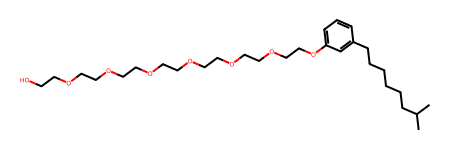

In [3]:
mol = Chem.MolFromSmiles('CC(C)CCCCCCc1cc(OCCOCCOCCOCCOCCOCCOCCO)ccc1')
mol

In [4]:
n_tertiary = len(mol.GetSubstructMatches(Chem.MolFromSmarts(tertiary)))
n_tertiary_2 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(tertiary_2)))
n_PO = len(mol.GetSubstructMatches(Chem.MolFromSmarts(PO)))
n_EO = len(mol.GetSubstructMatches(Chem.MolFromSmarts(EO)))
n_p1 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(p1)))
n_p2 = len(mol.GetSubstructMatches(Chem.MolFromSmarts(p2)))

n_secondary = len(mol.GetSubstructMatches(Chem.MolFromSmarts(secondary)))
n_benzene = len(mol.GetSubstructMatches(Chem.MolFromSmarts(benzene)))
n_tertiary_non_2 = n_tertiary-n_tertiary_2-n_PO

In [5]:
number_of_carbons = (n_p1 + n_p2 +n_secondary)+6.9*n_tertiary_2 + 0.71 * n_tertiary_non_2 + 2 * (n_PO+n_EO)+3.5 * n_benzene
Lc = 1.5 + 1.265 * number_of_carbons
L = 1.3 * Lc

In [67]:
interfacial_area = 61
L = 40
xi = 191

In [88]:
C_range = np.linspace(start = 0.016, stop = 0.5, num =10)

In [89]:
temp_range = np.linspace(25, 90, 10)

In [101]:
#HLDs = HLD_calculation(8, -1, 30, temp_range, Type = 'Nonionic')
HLDs = np.array([-1, -0.5, 0, 0.5, 0.5, 1])
H_range = (-HLDs/L)

In [9]:
def R_calculation(H, interfacial_area, concentrations, xi):
    Rw_range = 3/((concentrations/1000)*6E23*interfacial_area*1E-24)
    Ro_range = 1/(H[:,None]+1/Rw_range[None,:])

In [98]:
Rw_range = 3/((C_range/1000)*6E23*interfacial_area*1E-24)

In [97]:
Ros = 1/(np.abs(H_range[:, None])+1/Rw_range[None, :])

In [95]:
Rw_range

array([5122.95081967, 1174.68935992,  663.40370327,  462.22112659,
        354.66582598,  287.71642669,  242.02917258,  208.86322708,
        183.69146365,  163.93442623])

In [96]:
Ros

array([[-26.10638876, -26.56133425, -27.03241727, -27.52051195,
        -28.02655672, -28.55156031, -29.0966085 , -29.66287158,
        -30.25161275, -30.86419753],
       [-20.35079341, -20.62619288, -20.90914836, -21.19997513,
        -21.49900627, -21.80659393, -22.12311069, -22.44895109,
        -22.78453325, -23.13030069],
       [-16.67459636, -16.85903449, -17.04759841, -17.24042811,
        -17.43767002, -17.63947731, -17.84601035, -18.0574371 ,
        -18.27393357, -18.49568434],
       [-14.12333627, -14.25542942, -14.39001678, -14.52716968,
        -14.66696218, -14.80947122, -14.95477676, -15.10296193,
        -15.25411319, -15.40832049],
       [-12.24917767, -12.34841633, -12.44927612, -12.55179708,
        -12.65602061, -12.76198946, -12.86974786, -12.9793415 ,
        -13.09081769, -13.20422535],
       [-10.81414663, -10.89142172, -10.96980914, -11.04933306,
        -11.1300184 , -11.21189078, -11.2949766 , -11.37930302,
        -11.46489805, -11.55179053],
       [ -

In [40]:
Rws = np.ones((100,1))*Rw_range

In [15]:
NACs = 0.5*(1/Ros + 1/Rw_range)

In [16]:
NACs_bin = (NACs<1/xi).astype(int)

In [17]:
temps, concs = np.meshgrid(temp_range, C_range)

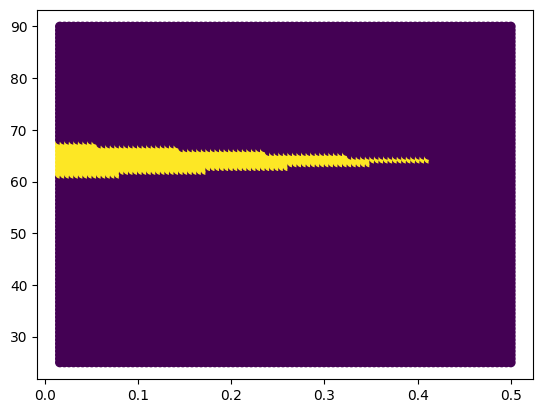

In [18]:
plt.scatter(concs.flatten(), temps.flatten(), c = np.transpose(NACs_bin))

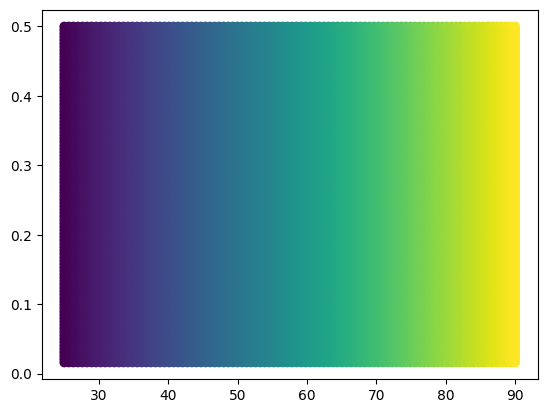

In [242]:
plt.scatter(temps.flatten(), concs.flatten(), c = np.ones((100,1))*HLDs[None,:])